# Predicting Term Deposit Subscription with CatBoost

**Assigned algorithm:** CatBoost

## 1. Introduction

Banks run phone marketing campaigns to convince clients to open a term deposit. These campaigns take time and money, and calling everyone in the client database isn't efficient — most people will say no. If we can predict in advance which clients are more likely to subscribe, the bank can prioritize calls and get a better return on the campaign.

**Problem we're solving:** given information about a client and their previous contact with the bank, predict whether they will subscribe to a term deposit (`yes`/`no`). Since the target has two possible outcomes, this is a **binary classification** problem.

**Why CatBoost:** the dataset mixes categorical features (job, marital status, education, contact type, month, previous outcome...) with numerical ones (age, balance, call duration...). CatBoost is built to handle categorical features directly, without needing to manually one-hot encode everything, and it tends to work well on tabular data like this out of the box. That combination is why it was assigned to us for this dataset.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from catboost import CatBoostClassifier, Pool

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Dataset Introduction

**Source:** this is the Bank Marketing dataset, originally collected from direct phone marketing campaigns run by a Portuguese banking institution between 2008 and 2010. It was first published on the UCI Machine Learning Repository (Moro, Cortez & Rita, *"A Data-Driven Approach to Predict the Success of Bank Telemarketing,"* Decision Support Systems, 2014) and is also mirrored on Kaggle as the "Bank Marketing Dataset." The specific file we were given, `bank.csv`, has 11,162 rows.

A quick note before diving in: this isn't the exact same file as the classic UCI `bank-full.csv` version that shows up in most tutorials. That version has about 45,000 rows and is heavily imbalanced (roughly 88% "no"). Ours has 11,162 rows, calls the target column `deposit` instead of `y`, and — as we'll see in the EDA — the classes are much closer to balanced. So we're following what's actually in this file rather than assuming the "textbook" numbers.


In [27]:
df = pd.read_csv("bank.csv")
df.shape


(11162, 17)

In [28]:
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [29]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [30]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


The dataset has **11,162 rows and 17 columns**. The target column is `deposit`, with values `yes`/`no`. Of the remaining 16 columns, 7 are numerical (`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`) and 9 are categorical (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`). `pandas` already reads them in as the right rough type, so no dtype fixing is needed.


## 3. Exploratory Data Analysis


In [31]:
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

No literal `NaN` values anywhere — but that's not the same as saying the data is complete. A few categorical columns use the string `"unknown"` as a value, which represents information that simply wasn't recorded for that client, even though it isn't a `NaN`. Let's check how common that is per column.


In [32]:
categorical_cols = df.select_dtypes(include="object").columns.drop("deposit")

unknown_counts = pd.DataFrame({
    "unknown_count": [(df[c] == "unknown").sum() for c in categorical_cols],
}, index=categorical_cols)
unknown_counts["unknown_pct"] = (unknown_counts["unknown_count"] / len(df) * 100).round(2)
unknown_counts[unknown_counts["unknown_count"] > 0].sort_values("unknown_pct", ascending=False)


/tmp/ipykernel_67969/1168232140.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.drop("deposit")


,unknown_count,unknown_pct
poutcome,8326,74.59
contact,2346,21.02
education,497,4.45
job,70,0.63


Four columns contain `"unknown"`: `poutcome` (74.6%), `contact` (21.0%), `education` (4.5%) and `job` (0.6%). `poutcome` being mostly unknown makes sense once you look at `pdays` — most clients were never contacted before this campaign (`pdays = -1`), so there's simply no outcome to record for them. That's not random missingness, it's a real, meaningful state ("no previous campaign"), so we're going to **keep `"unknown"` as its own category** rather than drop or impute it. CatBoost treats categorical columns as categories anyway, so an extra "unknown" category costs us nothing and the model can decide for itself whether it's informative.


In [33]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


No duplicate rows, so there's nothing to remove there.


deposit
no     5873
yes    5289
Name: count, dtype: int64
deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64


/tmp/ipykernel_67969/1649283797.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="deposit", order=["no", "yes"], palette="Set2")


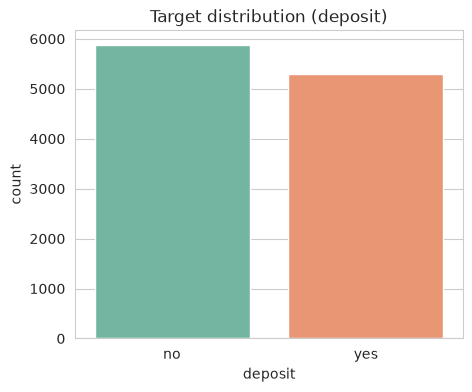

In [34]:
target_counts = df["deposit"].value_counts()
target_pct = df["deposit"].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="deposit", order=["no", "yes"], palette="Set2")
plt.title("Target distribution (deposit)")
plt.show()


The target is **roughly balanced**: 52.6% "no" vs 47.4% "yes". This is one of the places where this dataset clearly differs from the classic imbalanced UCI version — here, accuracy alone is actually a reasonably fair metric, since a model that just predicts the majority class wouldn't get particularly far. Still, we'll report precision, recall, F1 and ROC-AUC too, since in a real campaign the cost of missing an interested client (false negative) and wasting a call on someone who won't subscribe (false positive) aren't the same.


/tmp/ipykernel_67969/3381436058.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="deposit", y="duration", order=["no", "yes"], ax=axes[2], palette="Set2")


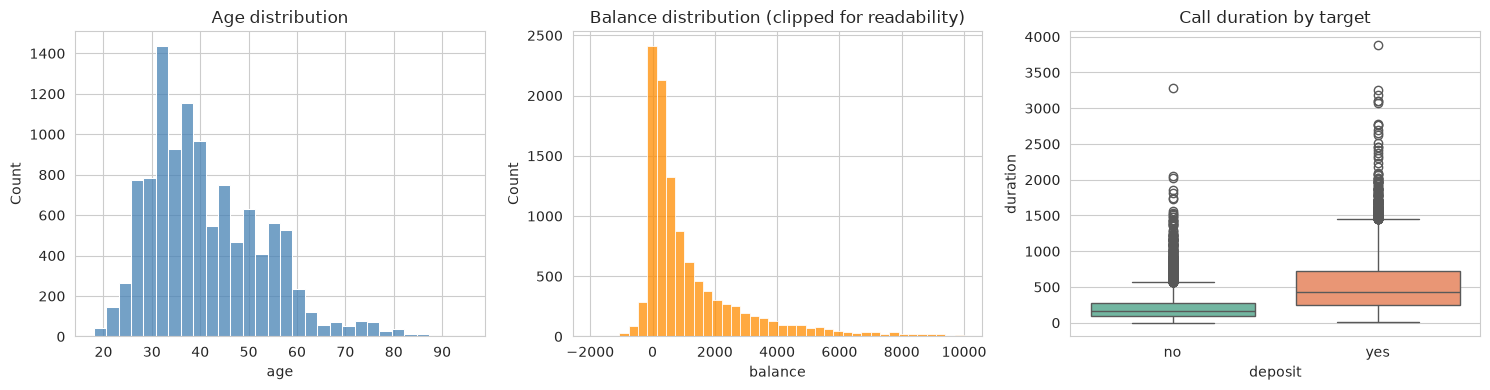

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["age"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Age distribution")

sns.histplot(df[df["balance"].between(-2000, 10000)]["balance"], bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Balance distribution (clipped for readability)")

sns.boxplot(data=df, x="deposit", y="duration", order=["no", "yes"], ax=axes[2], palette="Set2")
axes[2].set_title("Call duration by target")

plt.tight_layout()
plt.show()


Age is centered around the late 30s/early 40s with a long tail toward retirement age. Balance is heavily right-skewed with a handful of very large values (and some negative balances, which just means the client is overdrawn — not a data error). The clearest pattern here is `duration`: calls that end in a "yes" tend to run noticeably longer than calls that end in a "no". That's intuitive — a client who's actually interested stays on the phone longer — but it's also worth flagging early: `duration` is only known **after** the call has already happened, so in a real "who should we call next" system it wouldn't be available in advance. We'll come back to this in the conclusion.


/tmp/ipykernel_67969/860885666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="viridis")
/tmp/ipykernel_67969/860885666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="viridis")
/tmp/ipykernel_67969/860885666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="viridis")
/tmp/ipykernel_67969/860885666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

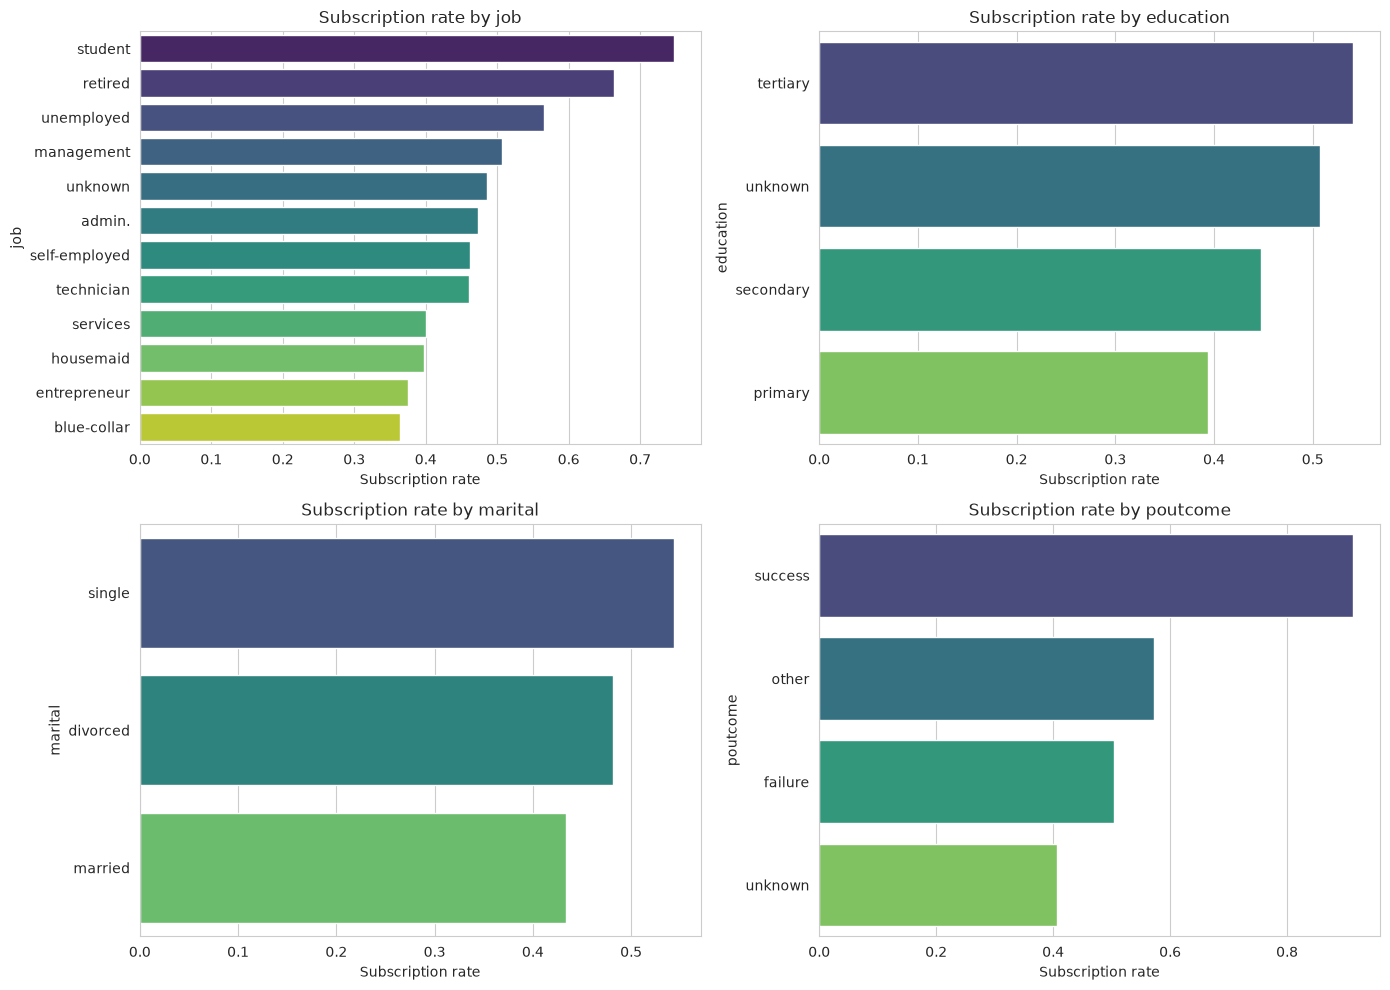

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, ["job", "education", "marital", "poutcome"]):
    rates = df.groupby(col)["deposit"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="viridis")
    ax.set_xlabel("Subscription rate")
    ax.set_title(f"Subscription rate by {col}")

plt.tight_layout()
plt.show()


A few things stand out:

- **`poutcome`**: clients whose previous campaign ended in `"success"` subscribe again 91% of the time — by far the strongest single signal in the categorical features. Makes sense — someone who already said yes once is a good bet to say yes again.
- **`job`**: students (75%) and retired people (66%) subscribe at much higher rates than blue-collar workers or entrepreneurs (~36-38%). Likely tied to available time and financial situation rather than the job title itself.
- **`education`**: subscription rate increases with education level (tertiary > secondary > primary), though the gap isn't huge.
- **`marital`**: single clients subscribe somewhat more than married or divorced ones.

None of this means these features *cause* someone to subscribe — it's just what's correlated with the outcome in this data.


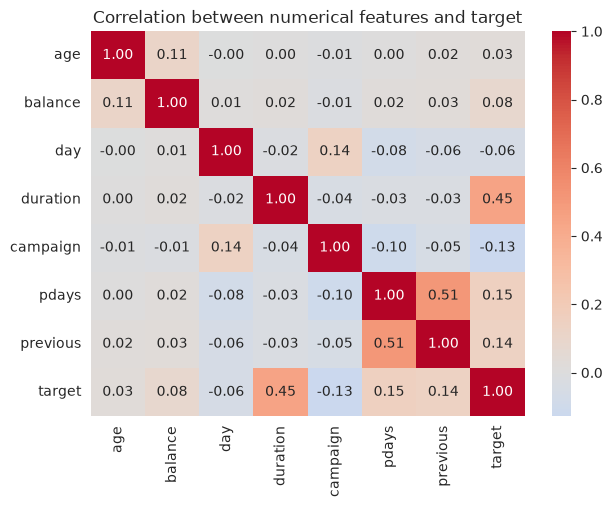

In [37]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
corr = df[numeric_cols].copy()
corr["target"] = (df["deposit"] == "yes").astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numerical features and target")
plt.show()


`duration` has the strongest correlation with the target (~0.45) by a clear margin — consistent with what we saw in the boxplot above. `pdays` and `previous` show a mild positive correlation (having been contacted before, and having more time since, is slightly associated with saying yes), and `campaign` (number of contacts in this campaign) is mildly negative — calling someone too many times in the same campaign doesn't seem to help. None of the other numerical features are strongly correlated with each other, so multicollinearity isn't a concern here. We didn't compute correlation for the categorical columns since Pearson correlation isn't a meaningful measure for unordered categories — that's what the bar plots above were for instead.


## 4. Data Preprocessing

Given what we found above, the preprocessing here is deliberately light:

- **Missing values:** there are no true `NaN`s, and we already decided to keep `"unknown"` as a valid category rather than imputing it — it carries real information (e.g. "never contacted before").
- **Categorical encoding:** we will **not** one-hot encode. CatBoost accepts categorical columns directly and handles them internally using its own encoding (based on target statistics), which usually works better than one-hot for columns with several categories like `job` or `month`, and keeps the feature space small.
- **Scaling:** CatBoost builds decision trees, which split on raw feature values and aren't affected by the scale of a feature (unlike distance-based or linear models). So we skip scaling for CatBoost entirely — we'll only add it later for the Logistic Regression comparison model, which does need it.
- **Train/test split:** we stratify on the target so the yes/no ratio stays consistent between train and test, and we fit everything only on the training set to avoid leaking test information into preprocessing decisions.


In [38]:
df_model = df.copy()
df_model["target"] = (df_model["deposit"] == "yes").astype(int)
df_model = df_model.drop(columns=["deposit"])

df_model["target"].value_counts()


target
0    5873
1    5289
Name: count, dtype: int64

In [39]:
categorical_features = ["job", "marital", "education", "default", "housing",
                         "loan", "contact", "month", "poutcome"]
numerical_features = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

X = df_model.drop(columns=["target"])
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

cat_feature_idx = [X.columns.get_loc(c) for c in categorical_features]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8929, 16)
Test shape: (2233, 16)


## 5. Baseline CatBoost Model

We start with a CatBoost model using mostly default settings, just to see where we stand before doing any tuning. This gives us a reference point to know whether tuning is actually worth the extra time later.


In [40]:
baseline_model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
baseline_model.fit(X_train, y_train, cat_features=cat_feature_idx)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]


### 5.1 Baseline Evaluation


In [41]:
def evaluate(y_true, y_pred, y_proba, label):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }
    print(f"--- {label} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    return metrics

baseline_metrics = evaluate(y_test, baseline_pred, baseline_proba, "Baseline CatBoost")
print()
print(classification_report(y_test, baseline_pred, target_names=["no", "yes"]))


--- Baseline CatBoost ---
Accuracy: 0.8692
Precision: 0.8377
Recall: 0.8979
F1: 0.8668
ROC-AUC: 0.9334

              precision    recall  f1-score   support

          no       0.90      0.84      0.87      1175
         yes       0.84      0.90      0.87      1058

    accuracy                           0.87      2233
   macro avg       0.87      0.87      0.87      2233
weighted avg       0.87      0.87      0.87      2233



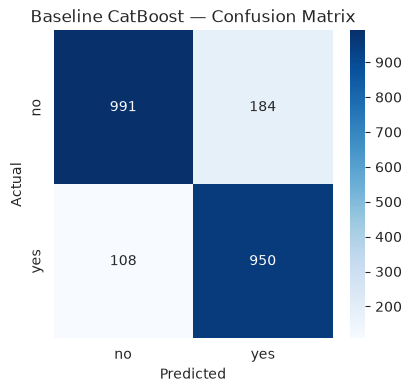

In [42]:
cm = confusion_matrix(y_test, baseline_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no", "yes"], yticklabels=["no", "yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline CatBoost — Confusion Matrix")
plt.show()


The baseline is already solid: ~87% accuracy and a ROC-AUC of 0.93, with precision and recall both close to each other (0.84 and 0.90). Recall being a bit higher than precision means the model leans slightly toward flagging more people as "yes" — in a call-center context that's not a bad trade-off, since missing an interested client (false negative) is arguably more costly than making one extra call to someone who says no (false positive). The confusion matrix backs this up: false negatives (108) are lower than false positives (184).


## 6. Hyperparameter Tuning

We'll tune the parameters that generally matter most for CatBoost:

- **`iterations`** — number of boosting rounds (trees). More can improve fit but risks overfitting and takes longer.
- **`learning_rate`** — how much each tree corrects the previous ones. Lower values need more iterations but usually generalize better.
- **`depth`** — how deep each tree can grow. Deeper trees capture more interactions but overfit more easily.
- **`l2_leaf_reg`** — L2 regularization on leaf values, helps control overfitting.

The guidelines suggest `GridSearchCV`/`RandomizedSearchCV`. We use **CatBoost's own built-in `randomized_search`** instead of scikit-learn's `RandomizedSearchCV` — it's the same idea (random sampling over a parameter grid with cross-validation) but it plays more smoothly with CatBoost's native categorical handling and `Pool` objects, and it avoids the extra one-hot encoding scikit-learn's version would otherwise force on us. We search a small, reasonable grid with 3-fold cross-validation instead of an exhaustive grid — a full grid search over these ranges would take far longer for a very similar result. Since the classes are close to balanced, accuracy would technically work as the scoring metric, but we optimize for **F1** anyway, since it stays meaningful even if the balance were to shift and it accounts for both false positives and false negatives directly.


In [43]:
train_pool = Pool(X_train, y_train, cat_features=cat_feature_idx)

param_grid = {
    "iterations": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5, 7],
}

tuned_model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, eval_metric="F1")

search_result = tuned_model.randomized_search(
    param_grid,
    train_pool,
    n_iter=15,
    cv=3,
    verbose=False,
    plot=False,
)

print("Best parameters found:", search_result["params"])



bestTest = 0.8404441847
bestIteration = 152


bestTest = 0.8603286385
bestIteration = 278


bestTest = 0.8347927612
bestIteration = 199


bestTest = 0.8546511628
bestIteration = 196


bestTest = 0.8412419449
bestIteration = 291


bestTest = 0.8608187135
bestIteration = 265


bestTest = 0.8504944735
bestIteration = 144


bestTest = 0.8626760563
bestIteration = 455


bestTest = 0.8618075802
bestIteration = 473


bestTest = 0.8603156049
bestIteration = 495


bestTest = 0.8566433566
bestIteration = 164


bestTest = 0.8496807893
bestIteration = 297


bestTest = 0.8631333722
bestIteration = 288


bestTest = 0.8621495327
bestIteration = 364


bestTest = 0.8516579407
bestIteration = 348

Training on fold [0/3]

bestTest = 0.854805726
bestIteration = 274

Training on fold [1/3]

bestTest = 0.8529005525
bestIteration = 298

Training on fold [2/3]

bestTest = 0.8595098378
bestIteration = 295

Best parameters found: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 300}


## 7. Tuned Model and Comparison

`randomized_search` already refits the model on the full training set using the best parameters found, so `tuned_model` is ready to evaluate directly on the test set.


In [44]:
tuned_pred = tuned_model.predict(X_test)
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = evaluate(y_test, tuned_pred, tuned_proba, "Tuned CatBoost")


--- Tuned CatBoost ---
Accuracy: 0.8679
Precision: 0.8349
Recall: 0.8989
F1: 0.8657
ROC-AUC: 0.9315


In [45]:
comparison = pd.DataFrame([baseline_metrics, tuned_metrics], index=["Baseline CatBoost", "Tuned CatBoost"])
comparison.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline CatBoost,0.8692,0.8377,0.8979,0.8668,0.9334
Tuned CatBoost,0.8679,0.8349,0.8989,0.8657,0.9315


Tuning didn't really move the needle here — accuracy, F1 and ROC-AUC are all within a fraction of a percent of the baseline, and recall is essentially unchanged. Precision moved down very slightly. In other words, the default CatBoost settings were already close to as good as this search space could get on this dataset — the model isn't struggling with underfitting or badly-set defaults, so there wasn't much room for tuning to help. This is a realistic outcome, not something we expected going in — for a dataset this size and this "clean," CatBoost's defaults are already well suited to the problem. We'll use the baseline model going forward since it's simpler and performs essentially the same.


## 8. Feature Importance and Model Interpretation


/tmp/ipykernel_67969/904149500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


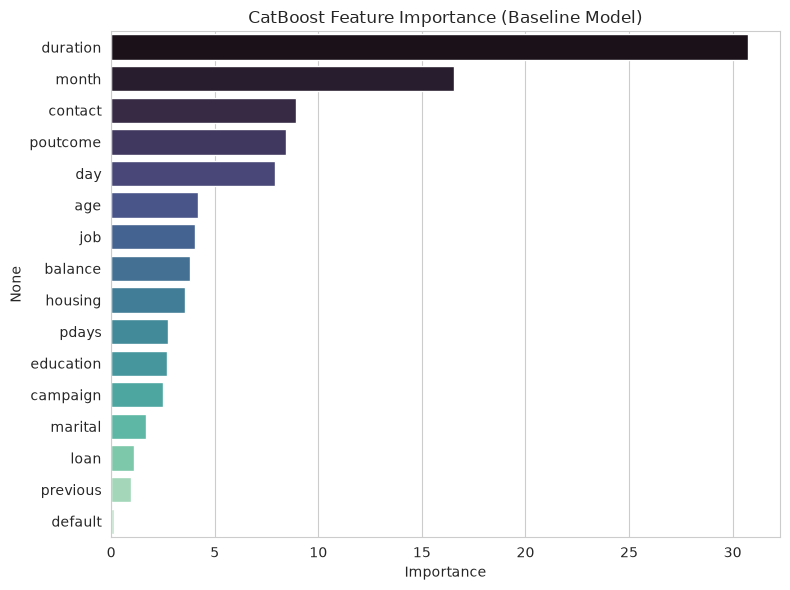

duration     30.748352
month        16.535733
contact       8.936081
poutcome      8.419811
day           7.927232
age           4.199699
job           4.040114
balance       3.822841
housing       3.554202
pdays         2.724320
education     2.704025
campaign      2.485712
marital       1.703295
loan          1.114186
previous      0.940347
default       0.144049
dtype: float64

In [46]:
importances = pd.Series(
    baseline_model.get_feature_importance(), index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance (Baseline Model)")
plt.tight_layout()
plt.show()

importances


`duration` dominates by a wide margin, followed by `month`, `contact` and `poutcome`. This lines up exactly with what we saw in the EDA — those were the features with the clearest visual relationship to the target. It's important to be careful here: this tells us the model **relies on** these features to make predictions, not that they *cause* someone to subscribe. `duration` in particular is a consequence of the client's interest, not a cause of it (nobody subscribes *because* the call was long — the call is long because they're interested). Features like `age`, `job` and `balance` matter much less to the model than they seemed to in the raw subscription-rate bar charts, which suggests a lot of their signal overlaps with what's already captured by the stronger features.

### 8.1 SHAP values

Feature importance tells us which features mattered *overall*, but not how a feature pushed any single prediction up or down. SHAP values give us that, per feature and per client.


In [48]:
%pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 693.0 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 2.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 2.5 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/home/hager/nti/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


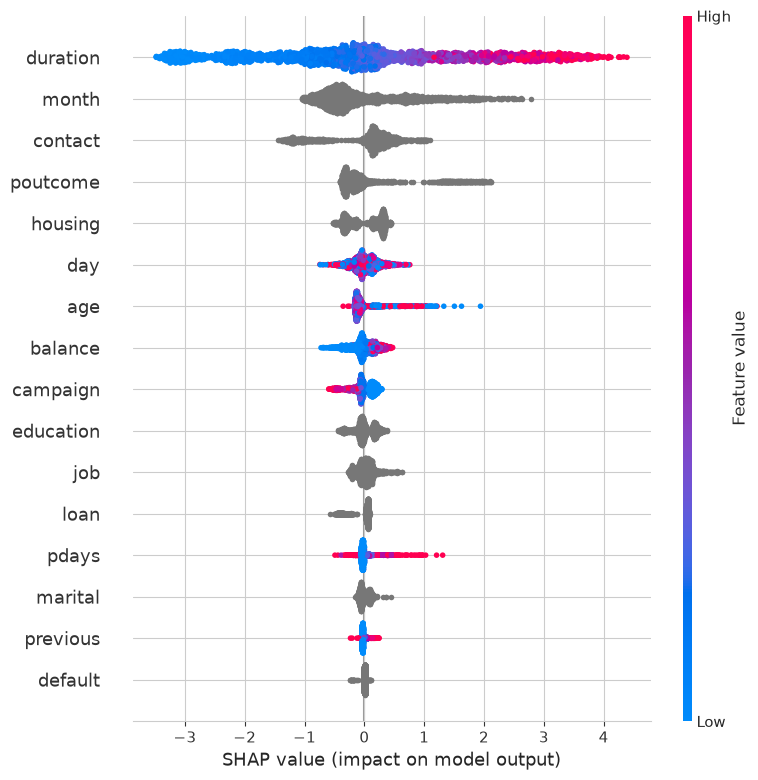

In [49]:
import shap

explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()


The SHAP summary plot agrees with the feature importance plot on the top features (`duration`, `month`, `contact`, `poutcome`), but adds direction: for `duration`, high values (red, longer calls) push predictions toward "yes," which matches what the boxplot showed back in the EDA. Let's also look at one individual client to see how this plays out for a single prediction.


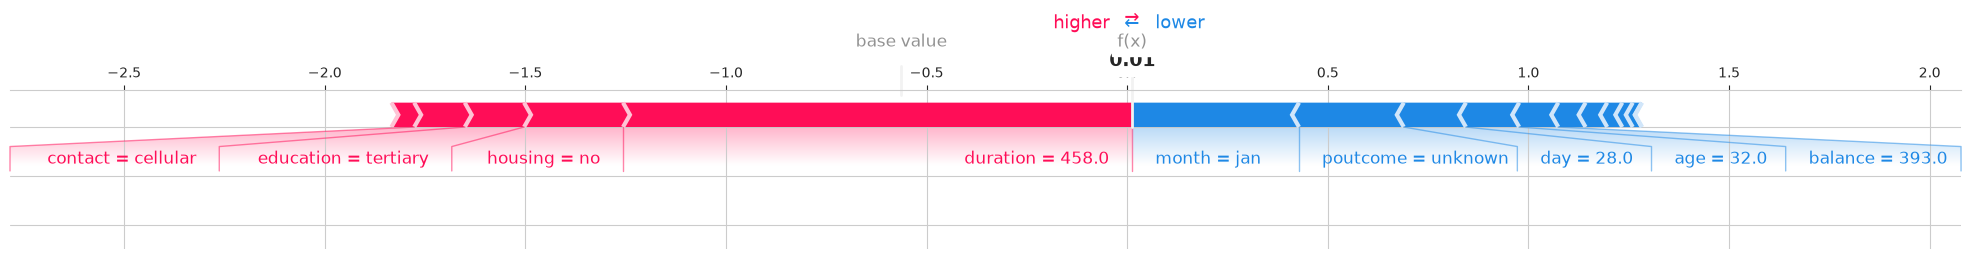

In [50]:
sample_idx = 0
shap.force_plot(
    explainer.expected_value, shap_values[sample_idx, :], X_test.iloc[sample_idx, :],
    matplotlib=True, show=False,
)
plt.tight_layout()
plt.show()


For this one client, we can see exactly which features pushed the prediction toward "yes" or "no" and by how much — this is the kind of thing that's much harder to get out of a global feature importance chart alone, and it's a nice thing to show live during the presentation.


## 9. Addressing the `duration` Issue

We flagged this in the EDA and it showed up again as the top feature above, so it's worth actually dealing with it rather than just mentioning it.

The problem: `duration` (how long the call lasted) is only known **after** the call has already happened. Everything we've evaluated so far answers the question *"can we predict the outcome of a call that has already taken place?"* — which is a valid question, but not the one a bank actually cares about before picking up the phone. The question they'd actually want answered **before** calling someone is: *"is this client worth calling in the first place?"*

To see how much `duration` is really carrying the model, we train the exact same kind of CatBoost model again, just without that one column, and compare it to the original.


In [51]:
features_no_duration = [c for c in X.columns if c != "duration"]
cat_feature_idx_no_duration = [features_no_duration.index(c) for c in categorical_features]

X_train_nd = X_train[features_no_duration]
X_test_nd = X_test[features_no_duration]

no_duration_model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
no_duration_model.fit(X_train_nd, y_train, cat_features=cat_feature_idx_no_duration)

nd_pred = no_duration_model.predict(X_test_nd)
nd_proba = no_duration_model.predict_proba(X_test_nd)[:, 1]

no_duration_metrics = evaluate(y_test, nd_pred, nd_proba, "CatBoost (no duration)")


--- CatBoost (no duration) ---
Accuracy: 0.7470
Precision: 0.7952
Recall: 0.6276
F1: 0.7015
ROC-AUC: 0.7987


In [52]:
duration_comparison = pd.DataFrame(
    [baseline_metrics, no_duration_metrics],
    index=["With duration (post-call model)", "Without duration (pre-call model)"],
)
duration_comparison.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
With duration (post-call model),0.8692,0.8377,0.8979,0.8668,0.9334
Without duration (pre-call model),0.7470,0.7952,0.6276,0.7015,0.7987


Removing `duration` costs a real, substantial amount of performance — ROC-AUC drops from 0.93 to about 0.80, and F1 drops from ~0.87 to ~0.70 (exact numbers above). That's a much bigger hit than we expected going in, and it confirms `duration` wasn't just topping a feature-importance chart by coincidence — it was genuinely carrying most of the model's ability to separate the two classes.

**Which model would we actually use?** Depends on the question being asked:
- If the goal is analyzing calls that already happened (e.g. "did this call go well, and why?") — the model **with** `duration` is legitimate and gives the strongest results.
- If the goal is deciding **who to call next**, before any call has happened — only the model **without** `duration` is realistic. It's noticeably weaker, but it's the honest answer to that question.

For a real "prioritize the next batch of calls" use case, we'd go with the no-duration model despite the lower scores, since the alternative would quietly assume information the bank doesn't actually have yet.


/tmp/ipykernel_67969/2972552204.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nd_importances.values, y=nd_importances.index, palette="mako")


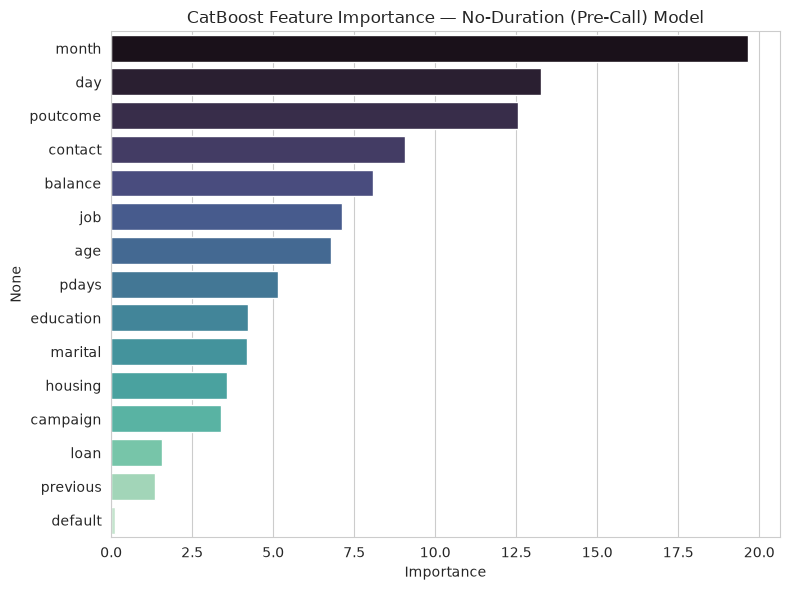

In [53]:
nd_importances = pd.Series(
    no_duration_model.get_feature_importance(), index=features_no_duration
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=nd_importances.values, y=nd_importances.index, palette="mako")
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance — No-Duration (Pre-Call) Model")
plt.tight_layout()
plt.show()


With `duration` out of the picture, `month` and `day` (timing of the campaign) move to the top, followed by `poutcome` and `contact`, with `balance` and `age` also becoming more relevant than they were before. This is a more believable set of features to base a "who should we call" decision on, since every one of them is known before the call is made.


## 10. Bonus: Comparison with Logistic Regression

As a bonus, we compare CatBoost against a simple Logistic Regression baseline on the same split, just to see how much the more complex, tree-based approach actually buys us. Logistic Regression needs one-hot encoded categoricals and scaled numerical features, which is exactly the kind of manual preprocessing we got to skip with CatBoost.


In [54]:
X_train_lr = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_lr = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)
X_test_lr = X_test_lr.reindex(columns=X_train_lr.columns, fill_value=0)

scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_lr_scaled, y_train)

lr_pred = lr_model.predict(X_test_lr_scaled)
lr_proba = lr_model.predict_proba(X_test_lr_scaled)[:, 1]

lr_metrics = evaluate(y_test, lr_pred, lr_proba, "Logistic Regression")


--- Logistic Regression ---
Accuracy: 0.8258
Precision: 0.8270
Recall: 0.7996
F1: 0.8131
ROC-AUC: 0.9072


In [55]:
final_comparison = pd.DataFrame(
    [baseline_metrics, tuned_metrics, no_duration_metrics, lr_metrics],
    index=["Baseline CatBoost", "Tuned CatBoost", "CatBoost (no duration)", "Logistic Regression"],
)
final_comparison.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline CatBoost,0.8692,0.8377,0.8979,0.8668,0.9334
Tuned CatBoost,0.8679,0.8349,0.8989,0.8657,0.9315
CatBoost (no duration),0.7470,0.7952,0.6276,0.7015,0.7987
Logistic Regression,0.8258,0.8270,0.7996,0.8131,0.9072


CatBoost (with `duration`) clearly outperforms Logistic Regression across every metric, most noticeably in F1 and recall. That's a reasonable outcome — Logistic Regression can only draw a linear boundary in the (encoded) feature space, while CatBoost's trees can pick up non-linear patterns and interactions between features like `poutcome` and `month` automatically. The trade-off is that Logistic Regression is far easier to interpret directly from its coefficients, and trains almost instantly, while CatBoost needs more compute and a feature-importance/SHAP plot rather than a simple coefficient table to explain itself. Even the no-duration CatBoost model holds up reasonably against Logistic Regression, despite giving up its strongest feature.


## 11. Conclusion

We set out to predict whether a bank client would subscribe to a term deposit after a marketing call, using the assigned CatBoost algorithm. The Bank Marketing dataset was a good match for it: a real mix of categorical and numerical features, no need for one-hot encoding, and a target that turned out to be close to balanced rather than the heavily skewed 88/12 split the "textbook" version of this dataset is known for.

**Main results:** the baseline CatBoost model (with `duration`) reached ~87% accuracy, an F1-score of ~0.87 and a ROC-AUC of 0.93. CatBoost's own built-in randomized search over `iterations`, `learning_rate`, `depth` and `l2_leaf_reg` barely changed these numbers — the default settings were already close to as good as this search space could produce, which itself is a useful finding: not every model needs heavy tuning to perform well.

**Most important features:** `duration`, `month`, `contact` and `poutcome` drove most of the baseline model's predictions, confirmed by both CatBoost's feature importance and SHAP values. `poutcome = success` in particular is a very strong signal — someone who said yes before is likely to say yes again.

**Did we address the `duration` leakage issue?** Yes — since `duration` is only known after a call happens, we retrained the same model without it to get a more realistic "who should we call next" model. That model scores noticeably lower (see the comparison table above), which confirms `duration` really was carrying a large share of the original model's performance rather than just topping a chart by coincidence. For an actual pre-call targeting use case, this no-duration model is the one we'd trust, even though its numbers are less flattering.

**Strengths of CatBoost for this dataset:** no need to manually encode 9 categorical columns, solid out-of-the-box performance, a built-in feature-importance output, and clean compatibility with SHAP for per-client explanations. It also clearly beat a Logistic Regression baseline on the same data.

**Limitations:** CatBoost is less directly interpretable than something like Logistic Regression without extra tools like SHAP, and training/tuning it takes meaningfully longer. The dataset itself has a built-in trap (`duration`) that's easy to miss if you don't stop to think about when each feature is actually available.

**Possible future improvements:** deploy the no-duration model as the actual pre-call scoring model, try feature engineering (e.g. combining `pdays`/`previous`/`poutcome` into a single "prior contact" feature), and expand the SHAP analysis to more individual clients for the presentation.
